In [11]:
from langgraph.graph import StateGraph , START ,END
from typing import TypedDict , Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int
    
    equation: str
    discriminant: float
    result: str
    

In [3]:
graph = StateGraph(QuadState)

In [5]:
def show_equation(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    
    equation = f"{a}x^2 + {b}x + {c} = 0"
    
    return {
        "equation": equation
    }

In [6]:
def calculate_discriminant(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    
    discriminant = b**2 - 4*a*c
    
    return {
        "discriminant": discriminant
    }

In [7]:
def real_roots(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    c = state['c']
    
    discriminant = state['discriminant']
    
    root1 = (-b + discriminant**0.5) / (2*a)
    root2 = (-b - discriminant**0.5) / (2*a)
    
    return {
        "result": f"Two real roots: {root1} and {root2}"
    }

In [8]:
def repeated_root(state: QuadState) -> QuadState:
    a = state['a']
    b = state['b']
    
    root = -b / (2*a)
    
    return {
        "result": f"One real root (repeated): {root}"
    }

In [9]:
def no_real_roots(state: QuadState) -> QuadState:
    return {
        "result": "No real roots"
    }

In [12]:
def check_condition(state: QuadState) -> Literal["real_roots", "repeated_root", "no_real_roots"]:
    discriminant = state['discriminant']
    
    if discriminant > 0:
        return "real_roots"
    elif discriminant == 0:
        return "repeated_root"
    else:
        return "no_real_roots"  

In [15]:
graph.add_node("show_equation",  show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)
graph.add_node("real_roots", real_roots)
graph.add_node("repeated_root", repeated_root)
graph.add_node("no_real_roots", no_real_roots)



ValueError: Node `show_equation` already present.

In [14]:

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation", "calculate_discriminant")

graph.add_conditional_edges("calculate_discriminant", check_condition)
graph.add_edge("real_roots", END)
graph.add_edge("repeated_root", END)
graph.add_edge("no_real_roots", END)


In [16]:
workflow = graph.compile()

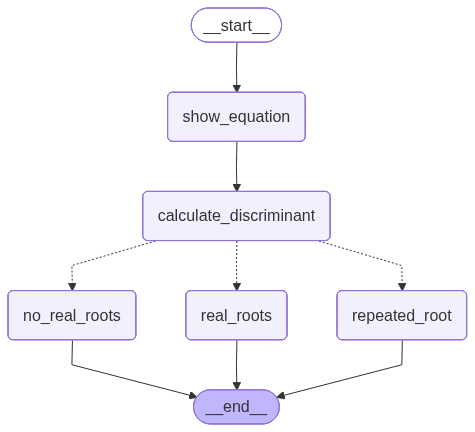

In [17]:
workflow

In [20]:
initial_state = {
    "a": -4,
    "b": -4,
    "c": 1
}
workflow.invoke(initial_state)

{'a': -4,
 'b': -4,
 'c': 1,
 'equation': '-4x^2 + -4x + 1 = 0',
 'discriminant': 32,
 'result': 'Two real roots: -1.2071067811865475 and 0.20710678118654757'}